# Consulta de ocupación del calendario de Airbnb en Málaga.

En este notebook realizamos una consulta de la ocupación de los alojamientos de Airbnb en Málaga, utilizando una ventana deslizante de 30 días con un desplazamiento de 7 días.

Nuestro objetivo con esta consulta es poder analizar la evolución temporal de la ocupación de los airbnb para ello, vamos a calcular:

- El porcentaje medio de la ocupación, indicándonos la fracción de los alojamientos que estuvieron reservados de media.
- El total de las reservas.

# Librerias

In [1]:
import sys
import pathlib
notebook_dir = pathlib.Path.cwd()
project_root = notebook_dir.parent.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    print(f'Directorio raíz añadido al path: {project_root}')

Directorio raíz añadido al path: /home/dani/Universidad/3o/2o-cuatri/SDPDII/Practicas/proy_SSDD_II


In [2]:
from src.kafka.consumer_kafka import create_kafka_stream_df, consumer_kafka_avro
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, window, avg, sum as spark_sum
import matplotlib.pyplot as plt

# Verificación cola de Apache Kafka.

Antes de iniciar el stream, vamos a comprobar que los datos de calendar están disponibles en la cola de kafka. Para ello, utilizamos el consumidor para leer y mostrar por pantalla los mensajes del topic de calendar, utilizamso un timeout de 10 segundos.

In [3]:
consumer_kafka_avro(
    topic = 'airbnb_calendar_gold',
    idle_timeout_seconds = 10,
    log_to_file = False
)

2026-05-06 17:40:51,547 [INFO] Escritura de logs en archivo desactivada.
2026-05-06 17:40:51,548 [INFO] --- INICIANDO MONITOR PARA: airbnb_calendar_gold ---
2026-05-06 17:40:51,635 [INFO] Configurando deserializador AVRO para airbnb_calendar_gold
2026-05-06 17:40:51,869 [INFO] Esquema detectado: airbnb_calendar_gold tiene 10 columnas.
2026-05-06 17:40:52,210 [INFO] Topic airbnb_calendar_gold: 10000 mensajes procesados.
2026-05-06 17:40:52,474 [INFO] Topic airbnb_calendar_gold: 20000 mensajes procesados.
2026-05-06 17:40:52,721 [INFO] Topic airbnb_calendar_gold: 30000 mensajes procesados.
2026-05-06 17:40:52,954 [INFO] Topic airbnb_calendar_gold: 40000 mensajes procesados.
2026-05-06 17:40:53,194 [INFO] Topic airbnb_calendar_gold: 50000 mensajes procesados.
2026-05-06 17:40:53,430 [INFO] Topic airbnb_calendar_gold: 60000 mensajes procesados.
2026-05-06 17:40:53,826 [INFO] Topic airbnb_calendar_gold: 70000 mensajes procesados.
2026-05-06 17:40:54,063 [INFO] Topic airbnb_calendar_gold: 80

# Sesión de Spark

Creamos la sesión de Spark para el procesamiento del stream. Hemos incluido los paquetes de integración con Apache Kafka y Avro, ya que los datos están serializados en este formato.

In [4]:
spark = (SparkSession.builder
        .appName("Notebook_Calendar_SlidingWindow")
        .config("spark.jars.packages", "org.apache.spark:spark-sql-kafka-0-10_2.13:4.1.1,org.apache.spark:spark-avro_2.13:4.1.1")
        .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark Session iniciada con éxito.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/06 17:42:29 WARN Utils: Your hostname, dani, resolves to a loopback address: 127.0.1.1; using 192.168.1.86 instead (on interface wlp62s0)
26/05/06 17:42:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/home/dani/Universidad/3o/2o-cuatri/SDPDII/Practicas/proy_SSDD_II/.venv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/dani/.ivy2.5.2/cache
The jars for the packages stored in: /home/dani/.ivy2.5.2/jars
org.apache.spark#spark-sql-kafka-0-10_2.13 added as a dependency
org.apache.spark#spark-avro_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-5ed5fe6b-a0fd-4cda-be44-e2709b9b4aa8;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.13;4.1.1 in central
	found org.apache.spark#spark-token-provider-ka

Spark Session iniciada con éxito.


# Consulta con Spark Streaming.

Hemos definido el proceamiento del streaming en tres pasos:

1. Lectura del stream desde el topic de kafka usando la función `create_kafka_stream_df`
2. Transformamos las variables `date` a `timestamp` para poder utilizarla como Event Time, y `booked` a entero.
3. Aplicamos una ventana de 30 días con un desplazamiento de 7 días, hemos introducido un watermark de 7 días para gestionar la llegada de los eventos tardios. Después, hemos calculado la ocupación media y el total de reservar por ventana.

In [5]:
# Read stream using imported function
df_calendar_raw = create_kafka_stream_df(spark, "airbnb_calendar_gold")

# Apply needed transformations and date cast
df_processed = (df_calendar_raw
        .withColumn("event_timestamp", col("date").cast("timestamp"))
        .withColumn("booked", col("booked").cast("integer"))
)

# Window and calculate availability
df_group = (df_processed
        .withWatermark("event_timestamp", "7 days")
        .groupBy(
            window(col("event_timestamp"), "30 days", "7 days")
        ).agg(
            (avg(col("booked")) * 100).alias("ocupacion_media"),
            spark_sum(col("booked")).alias("reservas_totales")
        )
)

# Sort chronologically
df_final = df_group.orderBy(col("window.start").desc())

# Inicio del stream.

Lanzamos la consulta de Spark en modo `complete`, por lo que en cada micro-bathc se reescribe la tabla completa de resultados. Esto se almacenan en memoria bajo el nombre de `tabla_resultados_calendar` para poder consultarlo posteriormente con SQL.

In [6]:
# Inicializate stream
query_calendar = (df_final.writeStream
        .outputMode("complete")
        .format("memory")
        .queryName("tabla_resultados_calendar")
        .start()
)

26/05/06 17:42:38 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-97cdcb71-1180-40dd-9938-8e1fd47eff31. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/05/06 17:42:38 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
26/05/06 17:42:38 WARN MicroBatchExecution: Disabling AQE since AQE is not supported in stateful workloads.


# Consulta de resultados.

Despues de inciar el stream y procesar los primeros mico-batches, hemos consultado la tabla en memoria con Spark SQL para visualizar la evolución de la ocupación por ventana temporal.

In [9]:
# Query
spark.sql("SELECT * FROM tabla_resultados_calendar").show(truncate=False)

+------------------------------------------+------------------+----------------+
|window                                    |ocupacion_media   |reservas_totales|
+------------------------------------------+------------------+----------------+
|{2026-09-24 02:00:00, 2026-10-24 02:00:00}|48.63942076727747 |28349           |
|{2026-09-17 02:00:00, 2026-10-17 02:00:00}|48.80901474477756 |61637           |
|{2026-09-10 02:00:00, 2026-10-10 02:00:00}|48.859892938027585|94925           |
|{2026-09-03 02:00:00, 2026-10-03 02:00:00}|48.90269103775383 |128261          |
|{2026-08-27 02:00:00, 2026-09-26 02:00:00}|48.82025941939469 |142272          |
|{2026-08-20 02:00:00, 2026-09-19 02:00:00}|48.788346716079886|142179          |
|{2026-08-13 02:00:00, 2026-09-12 02:00:00}|48.93006657058541 |142592          |
|{2026-08-06 02:00:00, 2026-09-05 02:00:00}|48.85354471209938 |142369          |
|{2026-07-30 02:00:00, 2026-08-29 02:00:00}|48.859035069658916|142385          |
|{2026-07-23 02:00:00, 2026-

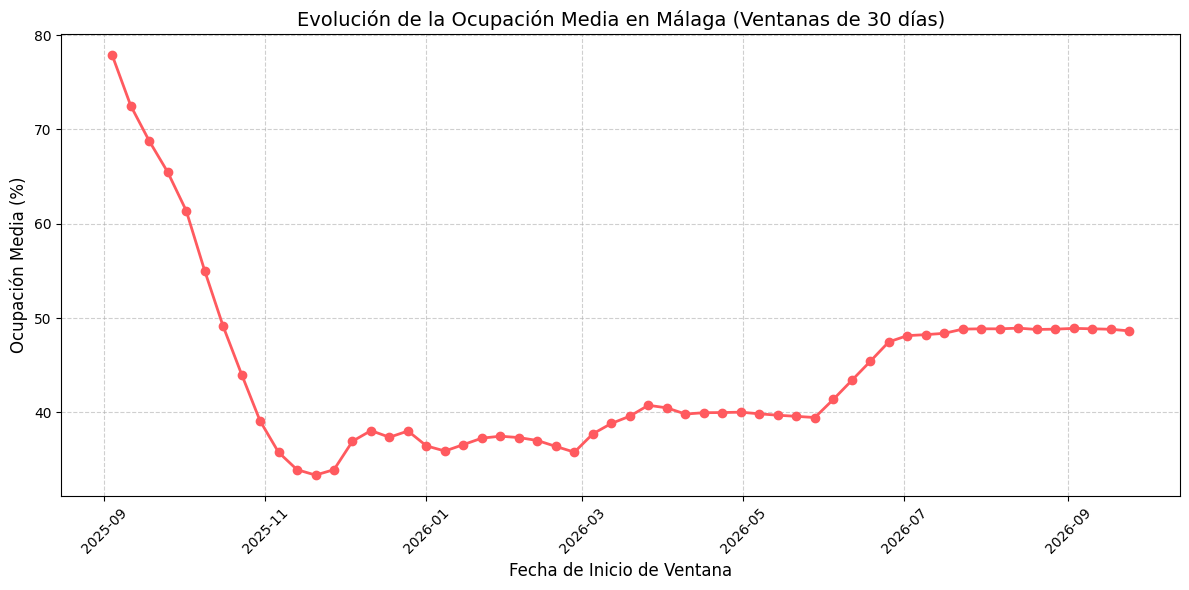

In [10]:
df_calendar = spark.sql("SELECT window.start as fecha, ocupacion_media FROM tabla_resultados_calendar").toPandas()

df_calendar = df_calendar.sort_values('fecha')

plt.figure(figsize=(12, 6))
plt.plot(df_calendar['fecha'], df_calendar['ocupacion_media'], marker='o', color='#ff5a5f', linewidth=2)

plt.title('Evolución de la Ocupación Media en Málaga (Ventanas de 30 días)', fontsize=14)
plt.xlabel('Fecha de Inicio de Ventana', fontsize=12)
plt.ylabel('Ocupación Media (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()